<a href="https://colab.research.google.com/github/Roseille/BME-i9400-2026/blob/meeting_07/checkins/Roseille_meeting07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [Open in Colab](https://colab.research.google.com/github/dmochow/BME-i9400-2026/blob/main/notebooks/meeting07_regression_studio.ipynb)

# BME i9400 — Meeting 7
## Studio: A Regression Baseline

**Fall 2026 · Wednesday, September 30**

Today you build the ten-feature regression model of Meeting 6 as a baseline: fit it on a training
set by the normal equations, evaluate it on held-out patients, diagnose it through its residuals and
its weights, and then add a ridge penalty to the loss and measure what regularisation does when data
are plentiful and when they are scarce.

**Agenda**

1. Loading and splitting the data
2. Fitting by the normal equations
3. Diagnosing the fit
4. Standardising the features
5. Ridge regression
6. Regularisation when data are scarce
7. Submitting your work

Section 1 is done for you — just read and run it. Sections 2 to 6 contain tasks marked `TODO` that
you are asked to complete. Each task ends with checks that must pass before you move on.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

---
## 1 — Loading and splitting the data

The data are the 442 diabetes patients of Meeting 6 (Efron, Hastie, Johnstone and Tibshirani,
*Annals of Statistics*, 2004): ten baseline measurements and a measure of disease progression one
year later.

The patients are split **before anything is fitted**. 80% form the **training set**, on which every
weight is computed. The remaining 20% form the **validation set**, which is used to evaluate the fit
and, in section 5, to choose the strength of the regularisation. Nothing about the model is computed
from the validation patients.

> `train_test_split` shuffles the rows with the given seed and divides them. Passing `random_state`
> makes the split reproducible, so your numbers match the ones quoted in this notebook.
>
> The split happens before any preprocessing that uses the data. Section 4 returns to this.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
plt.rcParams.update({"font.size": 12, "figure.dpi": 110})

data     = load_diabetes(scaled=False, as_frame=True)
features = ["age", "sex", "bmi", "bp", "s1", "s2", "s3", "s4", "s5", "s6"]
X = data.frame[features].values
y = data.frame["target"].values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=9400)

print(f"training set:   X_train {X_train.shape}, y_train {y_train.shape}")
print(f"validation set: X_val   {X_val.shape},  y_val   {y_val.shape}")
print(f"\nmean progression, training: {y_train.mean():.1f}    validation: {y_val.mean():.1f}")
data.frame.head(4)

training set:   X_train (353, 10), y_train (353,)
validation set: X_val   (89, 10),  y_val   (89,)

mean progression, training: 152.2    validation: 151.9


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0


---
## 2 — Fitting by the normal equations

From Meeting 6, with the intercept absorbed as a column of ones in the design matrix,

$$X^{\top}X\,w = X^{\top}y \qquad\Longrightarrow\qquad w^{*} = \left(X^{\top}X\right)^{-1}X^{\top}y$$

> `np.column_stack([a, B])` places the one-dimensional array `a` as the first column, followed by
> the columns of `B`. `np.ones(n)` gives the column of ones.
>
> `np.linalg.solve(A, b)` returns the `w` with `A @ w == b`. It is the way to compute $A^{-1} b$ in
> practice; `np.linalg.inv` is avoided.

Only the training set is used to compute $w^{*}$. Both sets are then used to make predictions.

In [ ]:
def design(A):
    """Place the column of ones in front of the feature matrix A."""
    # --- TODO: return the design matrix, shape (len(A), A.shape[1] + 1) ---
    #n_examples, n_features = A.shape
    #A = np.column_stack((np.ones(n_features), A)
    n_examples, n_features = A.shape
    return np.column_stack((np.ones(n_examples), A))
    #return A

def fit_ols(Xd, y):
    return np.linalg.solve(Xd.T @ Xd, Xd.T @ y)
#def fit_ols(Xd, y):
    """Least squares weights for the design matrix Xd and target y, by the normal equations."""
    # --- TODO: solve  X^T X w = X^T y  with np.linalg.solve ---
 #   w = np.linalg.solve(Xd.T@Xd, Xd.T@y)
    #from lecture 6
   # return None

Xd_train, Xd_val = design(X_train), design(X_val)
assert Xd_train is not None, "Fill in design()."
assert Xd_train.shape == (len(X_train), 11), f"Xd_train should have shape {(len(X_train), 11)}, got {Xd_train.shape}"
assert np.all(Xd_train[:, 0] == 1), "The first column should be all ones."

w_ols = fit_ols(Xd_train, y_train)
assert w_ols is not None, "Fill in fit_ols()."
assert w_ols.shape == (11,), f"w_ols should have 11 entries, got {w_ols.shape}"
residual = y_train - Xd_train @ w_ols
assert np.abs(Xd_train.T @ residual).max() < 1e-6 * np.abs(Xd_train.T @ y_train).max(), \
    "X^T (y - X w) should be zero at the solution: the normal equations (Meeting 6, section 4)."

# scikit-learn agrees
from sklearn.linear_model import LinearRegression
sk = LinearRegression().fit(X_train, y_train)
assert np.allclose(w_ols[0], sk.intercept_) and np.allclose(w_ols[1:], sk.coef_), "Weights differ from scikit-learn."

print("fitted weights:")
for name, coef in zip(["intercept"] + features, w_ols):
    print(f"  {name:<10} {coef:9.3f}")

fitted weights:
  intercept   -416.396
  age           -0.135
  sex          -19.818
  bmi            4.840
  bp             1.274
  s1            -1.614
  s2             1.172
  s3             1.060
  s4             6.981
  s5            85.347
  s6             0.516


---
## 3 — Diagnosing the fit

Three things are examined, all from section 6 of Meeting 6:

- **the error**, on the training set and on the validation set, as RMSE and $R^2$
- **the residuals**, plotted against the fitted values and as a histogram
- **the weights**, which section 4 makes comparable

> The RMSE is in progression units. $R^2$ is the fraction of the variance of $y$ that the model
> accounts for, relative to predicting the mean; use the mean of the set being evaluated, which is
> what `sklearn.metrics.r2_score` does.

                RMSE     R^2
training        53.6   0.521
validation      54.7   0.477


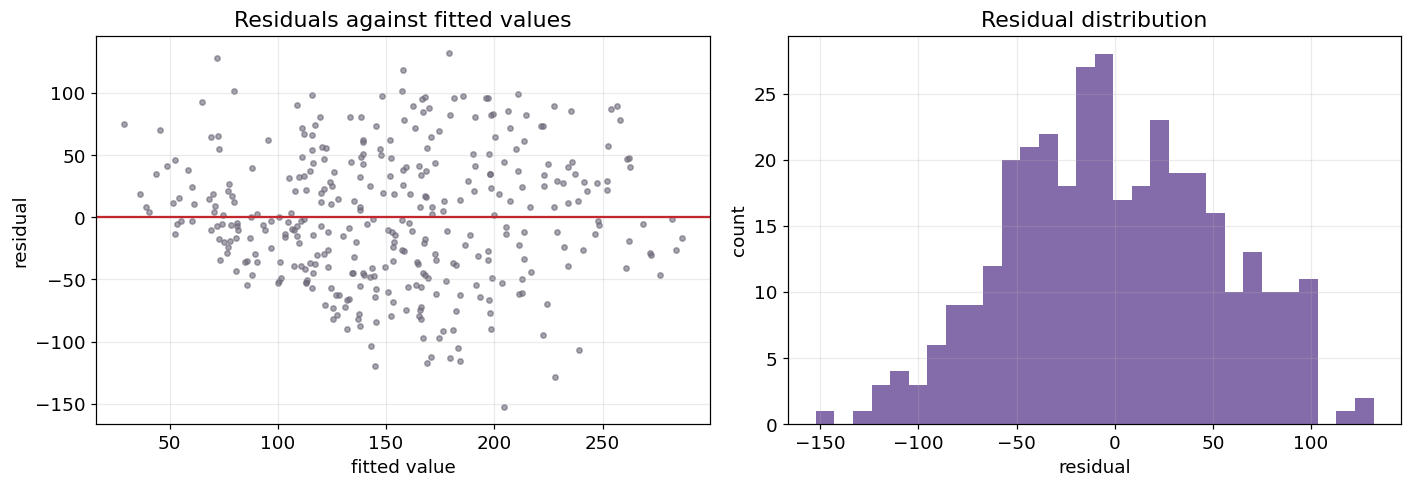

In [ ]:
def rmse(y_true, y_pred):
    # --- TODO: root mean squared error ---
    mse = np.sum((y_true-y_pred)**2)/y_true.shape[0]
    rmse = np.sqrt(mse)
    return rmse

def r_squared(y_true, y_pred):
    # --- TODO: 1 - (sum of squared residuals) / (sum of squared deviations of y_true from its mean) ---
    num = np.sum((y_true-y_pred)**2)
    y_bar = np.mean(y_true)
    denom = np.sum((y_true-y_bar)**2)
    R2 = 1 - num/denom
    return R2

pred_train = Xd_train @ w_ols
pred_val   = Xd_val   @ w_ols

assert rmse(y_train, pred_train) is not None and r_squared(y_train, pred_train) is not None, "Fill in both functions."
from sklearn.metrics import mean_squared_error, r2_score
assert np.isclose(rmse(y_val, pred_val), np.sqrt(mean_squared_error(y_val, pred_val))), "rmse disagrees with scikit-learn."
assert np.isclose(r_squared(y_val, pred_val), r2_score(y_val, pred_val)), "r_squared disagrees with scikit-learn."

print(f"{'':<12}{'RMSE':>8}{'R^2':>8}")
print(f"{'training':<12}{rmse(y_train, pred_train):>8.1f}{r_squared(y_train, pred_train):>8.3f}")
print(f"{'validation':<12}{rmse(y_val,   pred_val):>8.1f}{r_squared(y_val,   pred_val):>8.3f}")

resid_train = y_train - pred_train
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
axes[0].scatter(pred_train, resid_train, s=12, alpha=0.6, color="#6e6878")
axes[0].axhline(0, color="#c1272d", lw=1.5)
axes[0].set_xlabel("fitted value"); axes[0].set_ylabel("residual"); axes[0].set_title("Residuals against fitted values")
axes[1].hist(resid_train, bins=30, color="#5b3a8e", alpha=0.75)
axes[1].set_xlabel("residual"); axes[1].set_ylabel("count"); axes[1].set_title("Residual distribution")
for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

#R^2 0.5 => captures half of the variability of the data.

The validation RMSE is within about one unit of the training RMSE, and both $R^2$ values are near
0.5: the model generalises, and it accounts for about half of the variance in progression. The
residuals show no trend against the fitted values and are roughly symmetric. A baseline of this kind
is the reference point for every more complex model that follows in the course.

---
## 4 — Standardising the features

The weights of section 2 are in the units of their features, so their sizes cannot be compared: a
weight on `s5` (a logarithm, with a range of about 3) is not on the same footing as a weight on
`s1` (with a range of about 200). **Standardising** puts every feature on the same scale:

$$z_{ij} = \frac{x_{ij} - \mu_j}{s_j}$$

where $\mu_j$ and $s_j$ are the mean and the standard deviation of feature $j$.

> Standardising, also called **z-scoring**, centers each feature (Meeting 4) and then divides by its
> standard deviation, so that every feature has mean 0 and standard deviation 1. A weight then means:
> the change in the prediction for a one-standard-deviation change in the feature.
>
> **$\mu_j$ and $s_j$ are computed on the training set only**, and then applied to both sets.
> Computing them on all 442 patients would let information about the validation patients into the
> fit — a form of **leakage**, which Meeting 11 treats in full. `sklearn.preprocessing.StandardScaler`
> implements this discipline with `fit` on the training set and `transform` on both.

Standardising does not change the model's predictions: a change of units in the features is absorbed
by the weights, and the set of predictions the model can produce is unchanged. It changes what the
weights mean, and it is required before regularising (section 5), because a penalty on the size of
the weights treats every feature alike only if the features share a scale.

(10,)
(10,)
1.3888795684829153e-16 1.0
weights on standardised features (change in progression per standard deviation):

  s1       -55.82      (standard deviation of the feature: 34.59)
  s5        44.03      (standard deviation of the feature: 0.52)
  s2        35.20      (standard deviation of the feature: 30.04)
  bmi       22.12      (standard deviation of the feature: 4.57)
  bp        17.75      (standard deviation of the feature: 13.93)
  s3        13.55      (standard deviation of the feature: 12.78)
  sex       -9.87      (standard deviation of the feature: 0.50)
  s4         9.07      (standard deviation of the feature: 1.30)
  s6         5.73      (standard deviation of the feature: 11.11)
  age       -1.79      (standard deviation of the feature: 13.25)


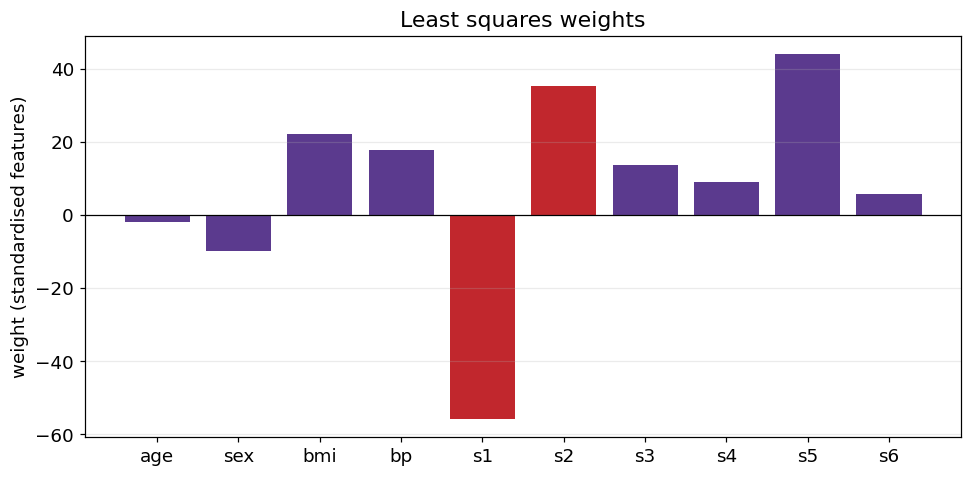

correlation between s1 and s2: 0.897
eigenvalues of the correlation matrix, smallest to largest: [0.009 0.076 0.415 0.529 0.609 0.673 0.974 1.225 1.535 3.955]
direction of smallest variance (weights on each feature):
   age:-0.00  sex:-0.00  bmi:-0.01  bp:+0.00  s1:-0.71  s2:+0.56  s3:+0.32  s4:+0.09  s5:+0.26  s6:+0.00


In [ ]:
# --- TODO: standardise with the training-set mean and standard deviation ---
mu      = np.mean(X_train, axis = 0)       # mean of each feature over X_train, shape (10,)
print(mu.shape)
sd      = np.std(X_train, axis = 0)      # standard deviation of each feature over X_train, shape (10,)   (use ddof=1)
print(sd.shape)
Z_train =(X_train - mu)/sd       # (X_train - mu) / sd
print(np.mean(Z_train), np.std(Z_train))
Z_val   = (X_val - mu)/sd       # (X_val   - mu) / sd    <- the same mu and sd

assert mu is not None and sd is not None and Z_train is not None and Z_val is not None, "Fill in all four."
assert mu.shape == (10,) and sd.shape == (10,), "mu and sd should have one entry per feature."
#assert np.allclose(Z_train.mean(axis=0), 0) and np.allclose(Z_train.std(axis=0, ddof=1), 1), \
#    "The columns of Z_train should have mean 0 and standard deviation 1."
#assert not np.allclose(Z_val.mean(axis=0), 0), "Z_val should be standardised with the training statistics, not its own."

Zd_train, Zd_val = design(Z_train), design(Z_val)
w_std = fit_ols(Zd_train, y_train)
#assert np.allclose(Zd_val @ w_std, pred_val), "The predictions should be identical to those of section 2."

print("weights on standardised features (change in progression per standard deviation):\n")
for j in np.argsort(-np.abs(w_std[1:])):
    print(f"  {features[j]:<6} {w_std[j + 1]:8.2f}      (standard deviation of the feature: {sd[j]:.2f})")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(features, w_std[1:], color=["#c1272d" if f in ("s1", "s2") else "#5b3a8e" for f in features])
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("weight (standardised features)"); ax.set_title("Least squares weights")
ax.grid(alpha=0.25, axis="y")
plt.tight_layout(); plt.show()

corr = np.corrcoef(Z_train.T)                                  # correlation matrix of the features, Meeting 4
evals, evecs = np.linalg.eigh(corr)
print(f"correlation between s1 and s2: {corr[4, 5]:.3f}")
print(f"eigenvalues of the correlation matrix, smallest to largest: {np.round(evals, 3)}")
print("direction of smallest variance (weights on each feature):")
print("   " + "  ".join(f"{f}:{v:+.2f}" for f, v in zip(features, evecs[:, 0])))

With every feature on the same scale, the sizes of the weights can be compared. Among the features
that are not collinear, `s5`, BMI, and blood pressure carry the largest weights, consistent with the
correlations seen in Meeting 6. The exception is the pair `s1` and `s2`. Total cholesterol receives a
weight of about $-56$ and LDL cholesterol about $+35$, each far larger in magnitude than the other
serum measures and of opposite sign, although neither feature has a strong relationship with the
target on its own.

This is the signature of **collinearity**. The two features are correlated at $r = 0.90$ — LDL is a
large component of total cholesterol — so their columns of $X$ point in nearly the same direction.
Increasing one weight while decreasing the other by a similar amount changes the predictions very
little, so the loss is nearly flat along that direction of weight space, and the minimum lands
wherever the noise in this particular sample happens to put it. The eigenvalues confirm it: the
direction of smallest variance in the feature data is dominated by `s1` and `s2` with opposite
signs, and it carries less than one percent of the variance of any single feature. A different
cohort would give a different pair of weights, possibly with the signs reversed. This is the
large-variance case of Meeting 6, section 5, and it is what ridge regression addresses.

---
## 5 — Ridge regression

Ridge regression adds a penalty on the size of the weights to the least squares loss:

$$L_{\text{ridge}}(w) = \|y - Xw\|^2 + \lambda \|w\|^2$$
hyper => above the model, picked
> $\lambda \ge 0$ (lambda) is a **hyperparameter**: a number chosen by the analyst rather than
> fitted from the training data. $\lambda = 0$ recovers least squares; as $\lambda$ grows, large
> weights become expensive and the solution shrinks toward zero.
>
> $\|w\|^2 = \sum_j w_j^2$ is the squared norm of the weight vector. The penalty is on the weights,
> not on the residuals: the model is asked to fit the data *and* to do so with small weights, and
> $\lambda$ sets the exchange rate between the two.
>
> The intercept is **not** penalised, since it only sets the overall level of the predictions. The
> sum in the penalty runs over $w_1, \dots, w_d$.

The solution follows the steps of Meeting 6, section 4, with one extra term. The gradient of
$\lambda \|w\|^2$ is $2\lambda w$, so

$$\nabla_w L_{\text{ridge}} = -2X^{\top}y + 2X^{\top}Xw + 2\lambda w = 0$$

$$X^{\top}Xw + \lambda w = X^{\top}y$$

$$\left(X^{\top}X + \lambda I\right) w = X^{\top}y$$

$$\boxed{\;w_{\text{ridge}} = \left(X^{\top}X + \lambda I\right)^{-1} X^{\top}y\;}$$

> $I$ is the identity matrix. Adding $\lambda I$ adds $\lambda$ to every diagonal entry of
> $X^{\top}X$. To leave the intercept unpenalised, the first diagonal entry of $I$ is set to zero.

Two effects follow from the extra term:

- $X^{\top}X + \lambda I$ is **always invertible** for $\lambda > 0$, even when $X^{\top}X$ is
  singular — the case of too few samples or exactly collinear features. The ridge solution exists
  and is unique whatever the data.
- In a direction of weight space along which the loss is nearly flat — the `s1`–`s2` trade-off of
  section 4 — the data contribute almost nothing, so the penalty dominates and pulls the weights
  toward zero. In directions where the data constrain the weights strongly, $X^{\top}X$ is large
  compared with $\lambda$ and the weights are barely changed. Ridge shrinks most where the data say
  least.

Because the penalty treats every weight alike, the features must share a scale: ridge is applied to
the standardised features of section 4.

**Choosing $\lambda$.** The training loss can only prefer $\lambda = 0$, since any penalty raises the
training error. $\lambda$ is chosen by evaluating the fit on data that the weights were not computed
from: here the validation set. Meeting 11 replaces the single validation set with cross-validation.

least squares:         training RMSE 53.56    validation RMSE 54.66
ridge, lam =   39.8:   training RMSE 54.09    validation RMSE 53.49

weights on s1 and s2:   least squares -55.8, +35.2      ridge -5.0, -3.7
weights on bmi and s5:  least squares +22.1, +44.0      ridge +21.2, +22.9


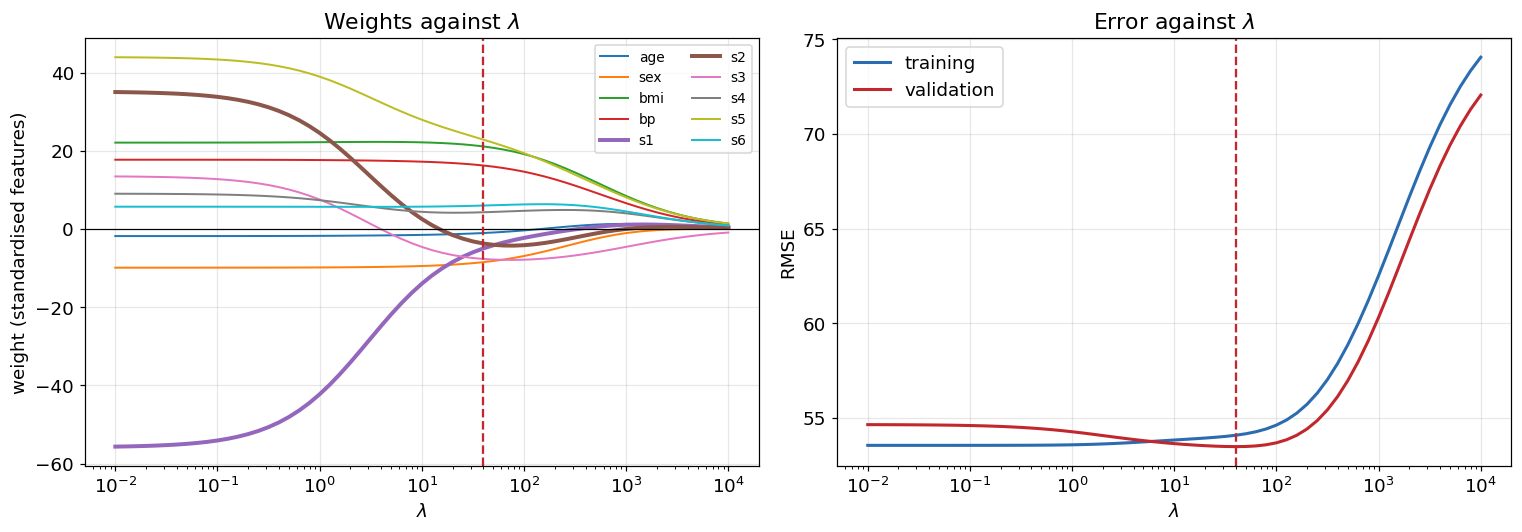

In [ ]:
def fit_ridge(Xd, y, lam):
    """Ridge weights for the design matrix Xd (first column all ones) and penalty lam.
    The intercept is not penalised."""
    # --- TODO: build I with a zero in position [0, 0], then solve  (X^T X + lam I) w = X^T y ---
    I = np.identity(Xd.shape[1])
    I[0] = 0 #Don't want regularize the intecept
    w_star = np.linalg.solve(Xd.T @ Xd + lam * I, Xd.T @ y )

    return w_star

assert fit_ridge(Zd_train, y_train, 0.0) is not None, "Fill in fit_ridge()."
assert np.allclose(fit_ridge(Zd_train, y_train, 0.0), w_std), "With lam = 0, ridge should equal least squares."
w_10 = fit_ridge(Zd_train, y_train, 10.0)
assert np.linalg.norm(w_10[1:]) < np.linalg.norm(w_std[1:]), "The penalty should shrink the weights."
assert np.isclose(w_10[0], w_std[0]), "The intercept should not be penalised."

# scikit-learn's Ridge uses the same convention: a penalty on the weights and none on the intercept
from sklearn.linear_model import Ridge
sk_ridge = Ridge(alpha=10.0).fit(Z_train, y_train)
assert np.allclose(w_10[1:], sk_ridge.coef_) and np.isclose(w_10[0], sk_ridge.intercept_), \
    "Disagrees with sklearn.linear_model.Ridge."

# The sweep: refit for every lambda, record the errors and the weights.
lambdas   = np.logspace(-2, 4, 61)
W         = np.array([fit_ridge(Zd_train, y_train, lam) for lam in lambdas])   # one row of weights per lambda
train_err = np.array([rmse(y_train, Zd_train @ w) for w in W])
val_err   = np.array([rmse(y_val,   Zd_val   @ w) for w in W])

# --- TODO: the index of the lambda with the smallest validation error ---
best = np.argmin(val_err)
assert best is not None, "Fill in best."
assert val_err[best] == val_err.min(), "best should index the smallest validation RMSE."
lam_best = lambdas[best]

ols_train, ols_val = rmse(y_train, Zd_train @ w_std), rmse(y_val, Zd_val @ w_std)
print(f"least squares:         training RMSE {ols_train:.2f}    validation RMSE {ols_val:.2f}")
print(f"ridge, lam = {lam_best:6.1f}:   training RMSE {train_err[best]:.2f}    validation RMSE {val_err[best]:.2f}")
print(f"\nweights on s1 and s2:   least squares {w_std[5]:+.1f}, {w_std[6]:+.1f}      ridge {W[best, 5]:+.1f}, {W[best, 6]:+.1f}")
print(f"weights on bmi and s5:  least squares {w_std[3]:+.1f}, {w_std[9]:+.1f}      ridge {W[best, 3]:+.1f}, {W[best, 9]:+.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for j, name in enumerate(features):
    axes[0].semilogx(lambdas, W[:, j + 1], lw=2.6 if name in ("s1", "s2") else 1.3, label=name)
axes[0].axhline(0, color="k", lw=0.8); axes[0].axvline(lam_best, ls="--", color="#c1272d")
axes[0].set_xlabel("$\\lambda$"); axes[0].set_ylabel("weight (standardised features)")
axes[0].set_title("Weights against $\\lambda$"); axes[0].legend(ncol=2, fontsize=9)
axes[1].semilogx(lambdas, train_err, lw=2, color="#2b6cb0", label="training")
axes[1].semilogx(lambdas, val_err,   lw=2, color="#c1272d", label="validation")
axes[1].axvline(lam_best, ls="--", color="#c1272d")
axes[1].set_xlabel("$\\lambda$"); axes[1].set_ylabel("RMSE"); axes[1].set_title("Error against $\\lambda$"); axes[1].legend()
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

On the full training set of 353 patients, ridge changes the error very little: the validation RMSE
falls from about 54.7 to about 53.5 at the best $\lambda$, a gain of about 2%. The weights, however,
change a great deal. `s1` and `s2` move from $-56$ and $+35$ to small values, while BMI and blood
pressure are barely affected until $\lambda$ is in the hundreds; the weight on `s5`, which is
correlated with several other features, is reduced by about half. The penalty acted first and
hardest on the pair that the data could not resolve, and left alone the weights that the data
determined well. With 353 patients and 11 weights, least squares was already close to the best that
a linear model can do here. The case in which regularisation matters is the next section.

---
## 6 — Regularisation when data are scarce

Meeting 6 showed that the scatter of the fitted weights grows as the number of patients falls.
Biomedical cohorts are often small — a pilot study of thirty patients is common — and that is where
regularisation matters. Repeat sections 4 and 5 on a training set of **30 patients**, keeping the
same validation set.

> `rng.permutation(n)` returns the integers $0, \dots, n-1$ in a random order; taking the first 30
> selects a random subset of the training rows. The standardisation statistics are recomputed on the
> 30 patients, since they are now the entire training set.

In [ ]:
rng  = np.random.default_rng(0)
rows = rng.permutation(len(X_train))[:30]
X_small, y_small = X_train[rows], y_train[rows]

# --- TODO: standardise with the statistics of the 30 patients, then fit least squares and ridge (lam = 10) ---
mu_s, sd_s    = X_small.mean(axis=0), X_small.std(axis=0, ddof = 1)       # mean and standard deviation of each feature over X_small
Zd_small      = design((X_small - mu_s)/sd_s)           # design matrix of the standardised 30-patient training set
Zd_val_s      = design((X_val - mu_s)/sd_s)             # the validation set, standardised with mu_s and sd_s (Train mu and sd, don't use test!)
w_small_ols   = fit_ols(Zd_small, y_small)
w_small_ridge = fit_ridge(Zd_small, y_small, lam=10)              # lam = 10

assert w_small_ols is not None and w_small_ridge is not None, "Fill in all of the TODOs."
assert Zd_small.shape == (30, 11) and Zd_val_s.shape == (len(X_val), 11), "Check the shapes of the design matrices."
assert np.allclose(Zd_small[:, 1:].mean(axis=0), 0), "Standardise with the 30-patient statistics."

val_ols   = rmse(y_val, Zd_val_s @ w_small_ols)
val_ridge = rmse(y_val, Zd_val_s @ w_small_ridge)
print(f"30 training patients,  validation RMSE:   least squares {val_ols:.1f}     ridge (lam = 10) {val_ridge:.1f}")
print(f"353 training patients, validation RMSE:   least squares {ols_val:.1f}     ridge (lam = 10) {rmse(y_val, Zd_val @ w_10):.1f}")
print(f"\nnorm of the weight vector, 30 patients:   least squares {np.linalg.norm(w_small_ols[1:]):.0f}     ridge {np.linalg.norm(w_small_ridge[1:]):.0f}")
print(f"norm of the weight vector, 353 patients:  least squares {np.linalg.norm(w_std[1:]):.0f}     ridge {np.linalg.norm(w_10[1:]):.0f}")
print(f"\nweights on s1 and s2 from 30 patients:    least squares {w_small_ols[5]:+.0f}, {w_small_ols[6]:+.0f}     ridge {w_small_ridge[5]:+.1f}, {w_small_ridge[6]:+.1f}")
assert val_ridge < val_ols, "With 30 patients, ridge should beat least squares on the validation set."

30 training patients,  validation RMSE:   least squares 70.6     ridge (lam = 10) 56.4
353 training patients, validation RMSE:   least squares 54.7     ridge (lam = 10) 53.6

norm of the weight vector, 30 patients:   least squares 112     ridge 31
norm of the weight vector, 353 patients:  least squares 87     ridge 44

weights on s1 and s2 from 30 patients:    least squares -55, +62     ridge -0.4, +6.4


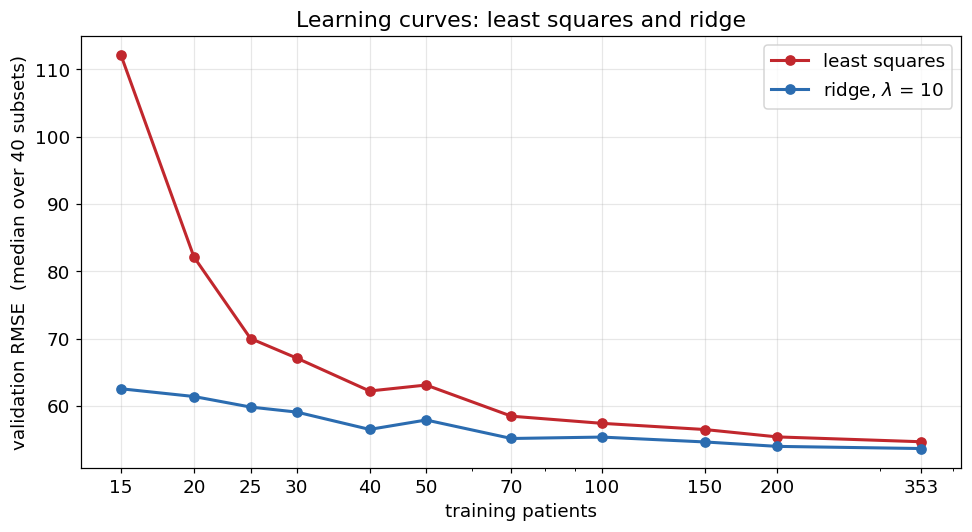

    15 patients:   least squares  112.1    ridge   62.5
    20 patients:   least squares   82.1    ridge   61.4
    25 patients:   least squares   70.0    ridge   59.8
    30 patients:   least squares   67.1    ridge   59.1
    40 patients:   least squares   62.2    ridge   56.5
    50 patients:   least squares   63.1    ridge   57.9
    70 patients:   least squares   58.5    ridge   55.1
   100 patients:   least squares   57.4    ridge   55.4
   150 patients:   least squares   56.5    ridge   54.6
   200 patients:   least squares   55.4    ridge   54.0
   353 patients:   least squares   54.7    ridge   53.6


In [ ]:
# Done for you: the same comparison at every training-set size, over 40 random subsets of each size.
sizes = [15, 20, 25, 30, 40, 50, 70, 100, 150, 200, 353]
curve = {"least squares": [], "ridge, $\\lambda$ = 10": []}
rng   = np.random.default_rng(7)
for n in sizes:
    errs = {k: [] for k in curve}
    for rep in range(40):
        rows = rng.permutation(len(X_train))[:n]
        m, s = X_train[rows].mean(axis=0), X_train[rows].std(axis=0, ddof=1)
        A, B = design((X_train[rows] - m) / s), design((X_val - m) / s)
        errs["least squares"].append(rmse(y_val, B @ fit_ols(A, y_train[rows])))
        errs["ridge, $\\lambda$ = 10"].append(rmse(y_val, B @ fit_ridge(A, y_train[rows], 10.0)))
    for k in curve:
        curve[k].append(np.median(errs[k]))

fig, ax = plt.subplots(figsize=(9, 5))
for (k, v), col in zip(curve.items(), ["#c1272d", "#2b6cb0"]):
    ax.plot(sizes, v, "o-", color=col, lw=2, label=k)
ax.set_xscale("log"); ax.set_xticks(sizes); ax.set_xticklabels(sizes)
ax.set_xlabel("training patients"); ax.set_ylabel("validation RMSE  (median over 40 subsets)")
ax.set_title("Learning curves: least squares and ridge")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

for n, a, b in zip(sizes, *curve.values()):
    print(f"  {n:4d} patients:   least squares {a:6.1f}    ridge {b:6.1f}")

Below about 50 training patients the two curves separate: with 30 patients ridge is roughly ten
progression units better than least squares on the validation patients, and with 15 patients — only
four more than the number of weights — least squares has become useless while ridge still performs
reasonably. With the full training set the curves nearly meet. Regularisation is a correction for
having too little data to determine the weights, and its benefit disappears as the data grow.

The 30-patient least squares weights also differ substantially from the full-data weights — `s1`
and `s2` now receive about $-55$ and $+62$ — which is the variance of Meeting 6, section 5, seen
directly: with few patients and collinear features the fit chases the noise, and large weights of
opposite sign on `s1` and `s2` are the usual result. Ridge returns both to a few units.

---
## 7 — Submitting your work

**Due at 11:59 PM EST on Wednesday, September 30.**

1. `Runtime ▸ Restart session and run all`. Every cell must run without error, and every check must
   pass.
2. `File ▸ Download ▸ Download .ipynb`.
3. Rename the file to `YOUR-GITHUB-USERNAME_meeting07.ipynb` and move it into the `checkins/` folder
   of your clone.
4. Commit in GitHub Desktop, push, and open a pull request.

### Two short questions

Answer in the cell below before you submit.

In [ ]:
# One or two sentences each.

# 1. Ridge barely improved the validation error with 353 training patients (section 5) but improved
#    it substantially with 30 (section 6). Using section 5 of Meeting 6, explain why the benefit
#    depends on the number of patients.
Q1 = "Ridge regression works best with a smaller sample size because the uncertainty in weights in ordinary least squares grows with the noise sigma^2 and shrinks with more data because XTX grows with n and the covariance equation is Cov(w*) = sigma^2(XTX)^-1. A small n also means that XTX can become nearly singular, blowing up the error due to collinearity. Covariance is what causes the weights to be unstable and overfit the training data. By adding a penalty we can reduce the validation error by optimizing the hyperparameter lambda that stabilizes the weights."

# 2. Section 5 chose lambda by the validation RMSE, and the same validation set was then used to
#    report the final error. Why is the reported error slightly optimistic, and what would fix it?
Q2 = "Lambda is the hyperparameter associated with the model, it's meant to prevent overfitting but still fit the training data. This is done by minimizing the validation error (RMSE). However, if this error is reported, then it's optimistic because the lambda was optimized based on that specific data. There needs to be a third held out validation set to evaluate the retrained model on fresh data. An example flow would be Feed Training Data into Model -> Minimize the Validation Error to get Optimal Lambda with a Validation Set -> Retrain Model Based on Hyperparameter + Training Data -> Test Model On New Test Set"

for name, ans in [("Q1", Q1), ("Q2", Q2)]:
    assert len(ans.strip()) >= 30, f"{name} looks empty or very short."
print("Answers recorded.")

Answers recorded.
